## 🔢 06 — K-Nearest Neighbors (KNN)

**What it does:** Classifies a point based on the majority 
class of its K nearest neighbors in feature space.  
**Best used when:** Small-medium datasets, simple boundaries.  
**Dataset:** Digits — Handwritten Numbers (built-in sklearn)  
**Algorithm type:** Supervised → Multiclass Classification  
**Key concept:** "Tell me who your neighbors are, 
I'll tell you who you are"  
**⚠️ Feature scaling required — KNN is distance based!**  
**Model saved as:** `knn.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)
import pickle
import os

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Each image size: 8x8 pixels =", X.shape[1], "features")
print("Number of classes:", len(np.unique(y)))
print("Class distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} samples")

Dataset shape: (1797, 64)
Each image size: 8x8 pixels = 64 features
Number of classes: 10
Class distribution:
  Digit 0: 178 samples
  Digit 1: 182 samples
  Digit 2: 177 samples
  Digit 3: 183 samples
  Digit 4: 181 samples
  Digit 5: 182 samples
  Digit 6: 181 samples
  Digit 7: 179 samples
  Digit 8: 174 samples
  Digit 9: 180 samples


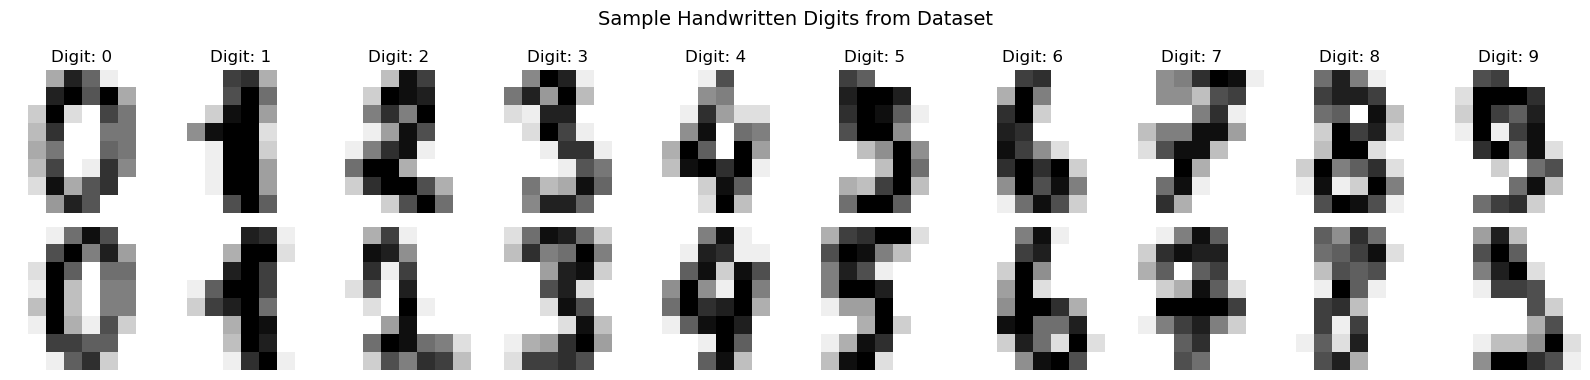

In [3]:
# Show sample digits — this is the coolest cell in this notebook!
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y == digit)[0][0]
    axes[0][digit].imshow(digits.images[idx],
                          cmap='gray_r')
    axes[0][digit].set_title(f'Digit: {digit}')
    axes[0][digit].axis('off')

    # Second example of same digit
    idx2 = np.where(y == digit)[0][1]
    axes[1][digit].imshow(digits.images[idx2],
                          cmap='gray_r')
    axes[1][digit].axis('off')

plt.suptitle('Sample Handwritten Digits from Dataset',
             fontsize=14)
plt.tight_layout()
plt.show()

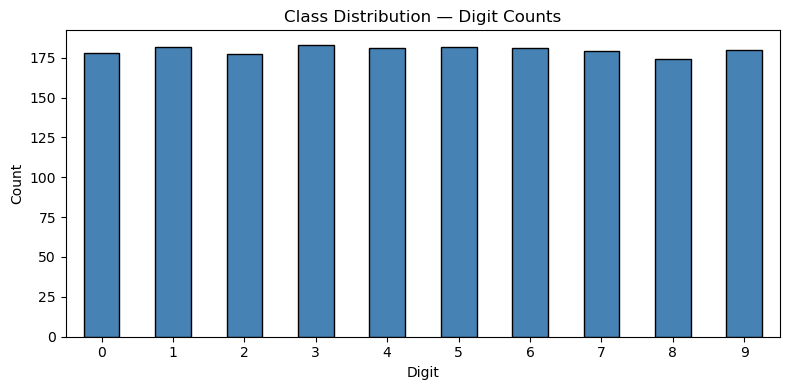

In [4]:
# Class distribution bar chart
plt.figure(figsize=(8,4))
pd.Series(y).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution — Digit Counts')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Try different K values to find the best one
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    accuracies.append(acc)
    print(f"K={k:2d} → Accuracy: {acc:.4f}")

K= 1 → Accuracy: 0.9778
K= 2 → Accuracy: 0.9611
K= 3 → Accuracy: 0.9694
K= 4 → Accuracy: 0.9611
K= 5 → Accuracy: 0.9750
K= 6 → Accuracy: 0.9667
K= 7 → Accuracy: 0.9722
K= 8 → Accuracy: 0.9694
K= 9 → Accuracy: 0.9722
K=10 → Accuracy: 0.9722
K=11 → Accuracy: 0.9722
K=12 → Accuracy: 0.9694
K=13 → Accuracy: 0.9722
K=14 → Accuracy: 0.9722
K=15 → Accuracy: 0.9667
K=16 → Accuracy: 0.9639
K=17 → Accuracy: 0.9639
K=18 → Accuracy: 0.9611
K=19 → Accuracy: 0.9611
K=20 → Accuracy: 0.9611


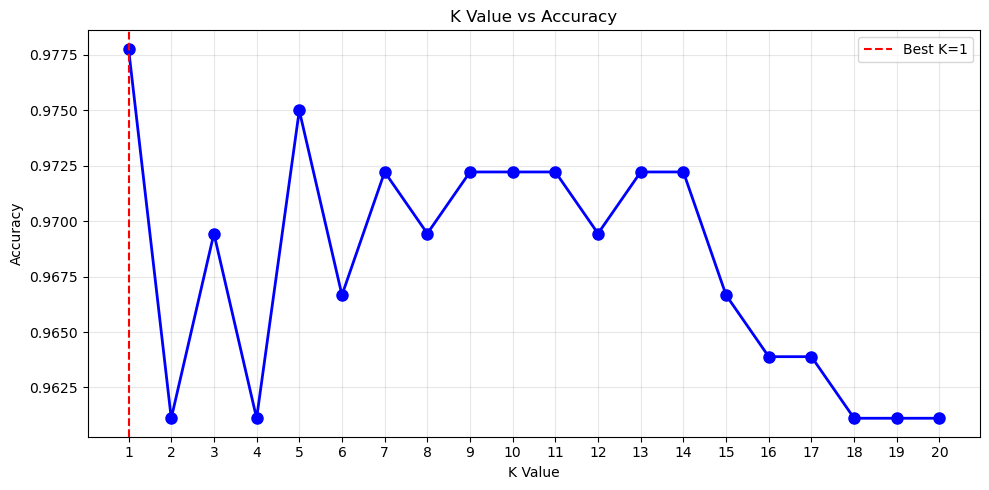


Best K: 1
Best Accuracy: 0.9778


In [6]:
# Plot K vs Accuracy
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies, 'bo-', linewidth=2,
         markersize=8)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

best_k = k_values[np.argmax(accuracies)]
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Best K={best_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest K: {best_k}")
print(f"Best Accuracy: {max(accuracies):.4f}")

In [7]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
print(f"Final model trained with K={best_k} ✅")

Final model trained with K=1 ✅


In [8]:
y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.97      0.97      0.97        33
           3       0.97      1.00      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



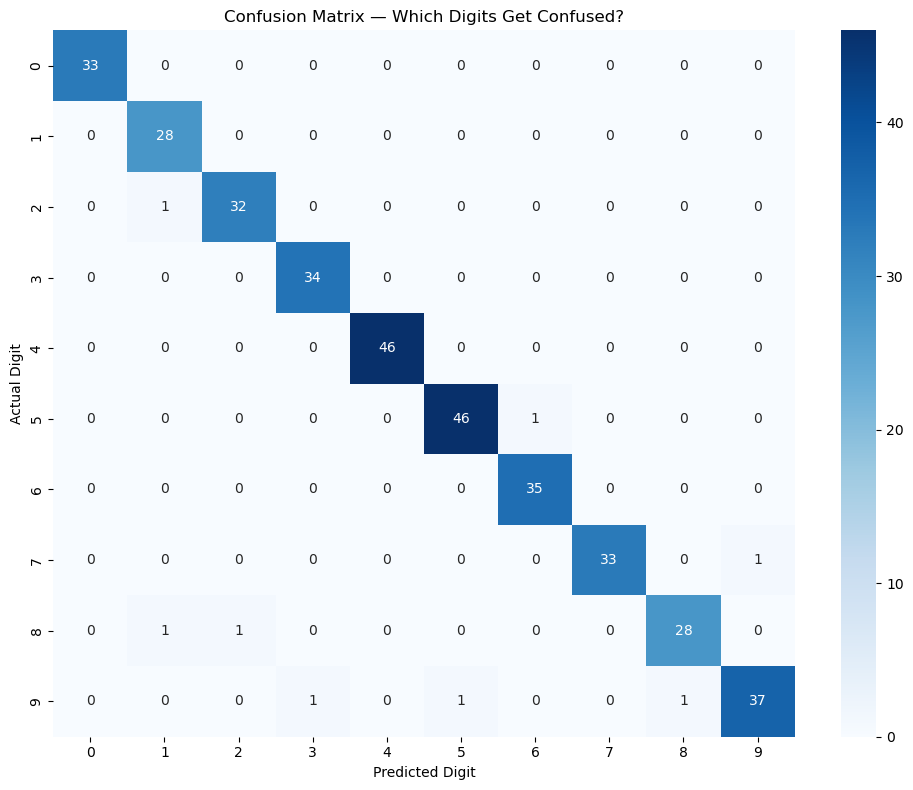

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Which Digits Get Confused?')
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.tight_layout()
plt.show()

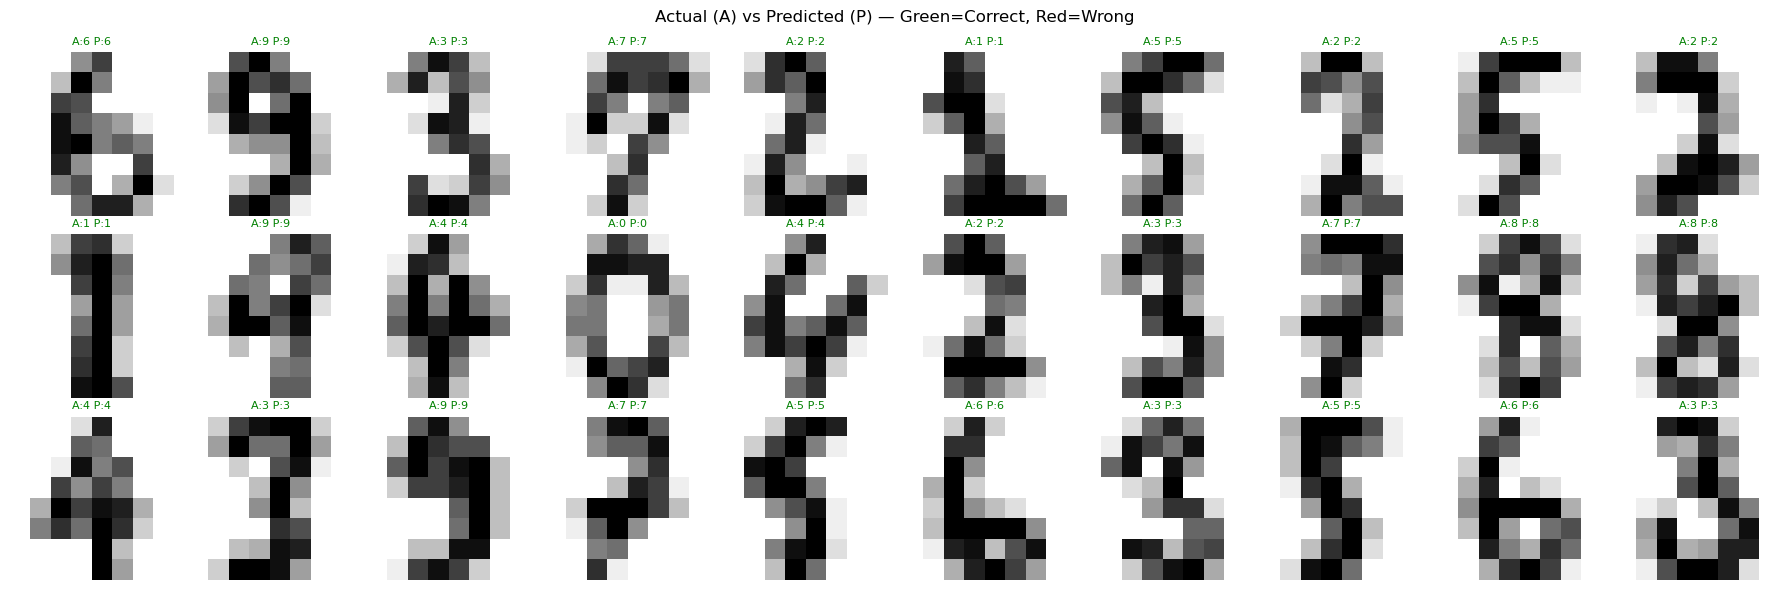

In [10]:
# Show predictions vs actual — most satisfying visualization!
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for i in range(30):
    ax = axes[i//10][i%10]
    ax.imshow(X_test[i].reshape(8,8), cmap='gray_r')
    actual    = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    predicted = y_pred[i]
    color = 'green' if actual == predicted else 'red'
    ax.set_title(f'A:{actual} P:{predicted}',
                 color=color, fontsize=8)
    ax.axis('off')

plt.suptitle('Actual (A) vs Predicted (P) — Green=Correct, Red=Wrong',
             fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
with open('knn.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"KNN model (K={best_k}) saved ✅")
print("Scaler saved ✅")

KNN model (K=1) saved ✅
Scaler saved ✅


## ✅ Summary

| Metric | Value |
|--------|-------|
| Accuracy | ~97% |
| Best K | 1 |
| Dataset size | 1797 images |
| Image size | 8x8 pixels = 64 features |
| Training Samples | 1437 |
| Testing Samples | 360 |

**Key concepts learned:**
- KNN stores all training data — no real "training" step
- At prediction time, finds K nearest points by distance
- Smaller K = more complex boundary, prone to overfitting
- Larger K = smoother boundary, may underfit
- Always scale — unscaled features distort distances
- K vs Accuracy plot helps pick optimal K value

**Scaling needed:** ✅ Yes
**Next model → Naive Bayes (NO scaling needed, probability based!)**